In [1]:
import pandas as pd
import joblib
import os
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, top_k_accuracy_score

# Set absolute paths relative to this notebook
X_test = pd.read_csv('../data/model_input/X_test.csv')
y_test = pd.read_csv('../data/model_input/y_test.csv').squeeze()

# Load trained models
rf = joblib.load('../models/race_prediction/random_forest.pkl')
xgb = joblib.load('../models/race_prediction/xgboost.pkl')


In [2]:
# Make predictions and probabilities
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

rf_probs = rf.predict_proba(X_test)
xgb_probs = xgb.predict_proba(X_test)


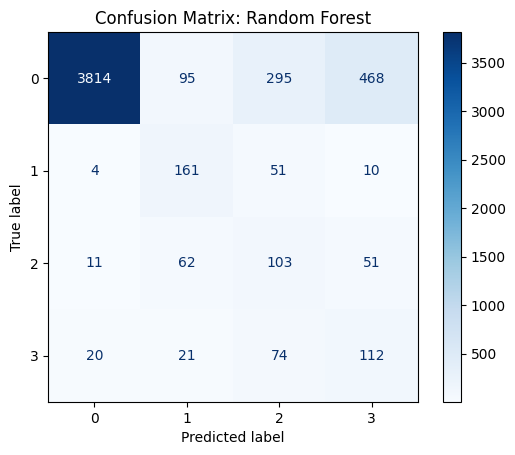

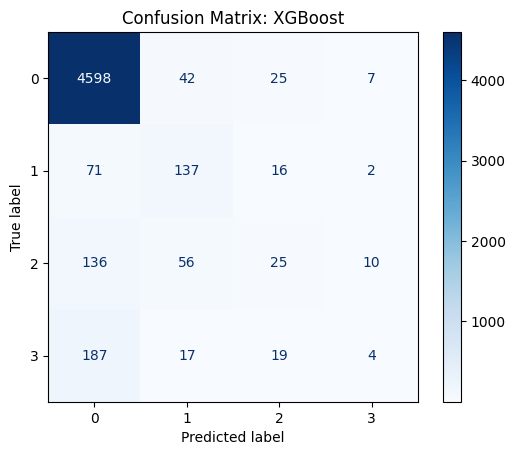

In [3]:
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrix(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

# Plot confusion matrices
plot_confusion_matrix("Random Forest", y_test, rf_pred)
plot_confusion_matrix("XGBoost", y_test, xgb_pred)


In [4]:
from sklearn.metrics import precision_recall_fscore_support
import plotly.express as px

def plot_f1_scores(y_true, y_pred, model_name):
    _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2, 3])
    labels = ['Non-Podium', '1st', '2nd', '3rd']
    fig = px.bar(
        x=labels,
        y=f1,
        title=f"Per-Class F1 Scores – {model_name}",
        labels={'x': 'Class', 'y': 'F1-Score'}
    )
    fig.show()

# Plot per-class F1
plot_f1_scores(y_test, rf_pred, "Random Forest")
plot_f1_scores(y_test, xgb_pred, "XGBoost")


In [5]:
print("Top-3 Accuracy – Random Forest:", top_k_accuracy_score(y_test, rf_probs, k=3))
print("Top-3 Accuracy – XGBoost:", top_k_accuracy_score(y_test, xgb_probs, k=3))


Top-3 Accuracy – Random Forest: 0.9387144992526159
Top-3 Accuracy – XGBoost: 0.98449177877429


In [6]:
sample_df = X_test.copy()
sample_df['Actual'] = y_test
sample_df['RF_Pred'] = rf_pred
sample_df['XGB_Pred'] = xgb_pred

# Show top 10 mismatches where RF or XGB got it wrong
sample_df[sample_df['Actual'] != sample_df['RF_Pred']].head(10)


,rolling_points_driver,constructor_dnf_rate,avg_finish_season,synergy,grid,constructor_avg_points,Actual,RF_Pred,XGB_Pred
1,4.666667,0.0,10.411765,3.647059,6,5.323529,0,3,0
2,5.666667,0.0,8.571429,4.000000,9,4.119048,0,2,0
5,2.666667,0.0,12.090909,1.295455,11,1.204545,0,3,0
9,2.000000,0.0,10.187500,2.419355,1,3.437500,0,2,0
13,11.333333,0.0,7.105263,12.395833,4,5.684211,0,3,0
14,4.333333,0.0,9.117647,2.393939,6,3.235294,0,2,0
16,2.000000,0.0,10.941176,2.400000,7,3.000000,0,2,0
17,2.000000,0.0,8.857143,2.043478,9,2.735294,3,2,0
18,5.333333,0.0,6.666667,2.062500,2,1.043478,1,2,1
19,2.000000,0.0,9.900000,1.157895,7,0.941176,0,2,0


In [7]:
import numpy as np

def plot_prediction_confidence(probs, model_name):
    max_conf = np.max(probs, axis=1)
    fig = px.histogram(max_conf, nbins=30, title=f"{model_name} Prediction Confidence Distribution", labels={'value': 'Max Confidence'})
    fig.show()

plot_prediction_confidence(rf_probs, "Random Forest")
plot_prediction_confidence(xgb_probs, "XGBoost")
